<a href="https://colab.research.google.com/github/biancavn/Exercicios_Aprendizado_Nao-Supervisionado/blob/main/10_Embeddings_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Embeddings e Redução da Dimensionalidade

**Objetivo.** Dado um conjunto de textos, gerar embeddings com BERT e investigar a estrutura dos dados via PCA, t-SNE e UMAP. Em seguida, identificar clusters e relacioná-los a categorias semânticas.

In [ ]:
sentences = [
    'I swap butter for olive oil in many recipes.',
    'Canberra is the capital of Australia.',
    'Ottawa is the capital city of Canada.',
    'Paris is the most populated city in France.',
    'Tokyo is among the most populous metropolitan areas worldwide.',
    'I prefer my coffee with no sugar and a splash of milk.',
    'The recipe for pasta carbonara is simple.',
    'A pinch of salt enhances sweetness in desserts.',
    'Alignment techniques reduce harmful outputs.',
    'Explainable AI highlights salient features for decisions.',
    'Transformer models enable long-range language dependencies.',
    'Black swan events stress-test portfolio resilience.',
    'The Sahara Desert spans much of North Africa.',
    'Inflation erodes real purchasing power of cash.',
    'Aromatics like garlic and onion build flavor early.',
    'Value stocks trade at lower multiples relative to fundamentals.',
    'Quantization reduces memory with minimal accuracy loss.',
    'Tax-loss harvesting offsets capital gains.',
    'Investing in technology can be risky.',
    'Fermented foods add acidity and complexity.',
    'Marinating tofu improves texture and taste.',
    'Vector databases power semantic search at scale.',
    'Distillation transfers knowledge from large to small models.',
    'The Great Barrier Reef lies off Australia’s northeast coast.',
    'Retrieval-augmented generation grounds answers in sources.',
    'Iceland lies on the Mid-Atlantic Ridge.',
    'The Baltic states border the eastern Baltic Sea.',
    'Multimodal learning aligns text with images and audio.',
    'Risk tolerance should guide position sizing.',
    'Time in the market beats timing the market.',
    'Behavioral biases can derail investment plans.',
    'Reinforcement learning fine-tunes policies from human feedback.',
    'Edge AI runs models under strict latency constraints.',
    'Deglazing lifts browned bits to make pan sauces.',
    'Tempering chocolate stabilizes cocoa butter crystals.',
    'What is the capital of France?',
    'Johannesburg is a major city but not South Africa’s capital.',
    'The Danube passes through multiple European capitals.',
    'The Amazon River carries one of the largest water volumes on Earth.',
    'A healthy emergency fund reduces forced selling.',
    'I batch-cook grains for quick lunches.',
    'Resting steak helps redistribute the juices.',
    'The Atacama is one of the driest deserts on the planet.',
    'Liquidity risk rises when trading volumes are thin.',
    'Mount Everest is the highest peak above sea level.',
    'Graph neural networks capture relational structure.',
    'Sourdough starter needs regular feedings to stay active.',
    'The stock market experienced a drop today.',
    'Umami-rich ingredients deepen savory dishes.',
    'Al dente pasta retains a slight bite after cooking.',
    'Rebalancing restores target asset allocation.',
    'Continual learning mitigates catastrophic forgetting.',
    'Bond duration measures sensitivity to interest-rate changes.',
    'Diffusion models synthesize high-fidelity images.',
    'Expense ratios compound against long-term returns.',
    'Self-supervised pretraining reduces labeled data needs.',
    'What country contains the city of Kyoto?',
    'Stir-frying requires high heat and constant movement.',
    'Covered calls generate income with capped upside.',
    'The Nile flows northward into the Mediterranean Sea.',
    'Causal inference distinguishes correlation from effect.',
    'Prompt engineering steers generative behavior reliably.',
    'Few-shot prompting improves generalization on new tasks.',
    'Growth investing prioritizes earnings expansion.',
    'The Alps stretch across several central European countries.',
    'The Andes form a continuous mountain range along South America.',
    'I cook vegetarian meals on weekdays to simplify planning.',
    'Natural language processing has advanced greatly.',
    'Sous-vide delivers precise temperature control.',
    'Diversification reduces idiosyncratic risk across holdings.',
    'Sharpe ratio evaluates risk-adjusted performance.',
    'Artificial intelligence is transforming the world.',
    'Credit spreads widen during economic uncertainty.',
    'Emerging markets add diversification but higher volatility.',
    'Mise en place speeds up weeknight cooking.',
    'The Caspian Sea is a landlocked body of water.',
    'Evaluation with benchmarks must avoid data leakage.',
    'Cairo sits along the Nile River delta.',
    'Federated learning trains models without centralizing data.',
    'Lagos is Nigeria’s largest city by population.',
    'Dollar-cost averaging smooths entry price over time.',
    'LoRA adapters enable efficient fine-tuning.',
    'I keep a jar of homemade pesto for pasta.',
    'New Delhi serves as the seat of India’s government.',
    'I like to cook Italian dishes on Sundays.',
    'Roasting vegetables caramelizes natural sugars.',
    'ETFs provide broad market exposure with intraday liquidity.',
    'Proofing time affects a bread’s crumb structure.'
]
#lista de frases aleatorias embaralhadas - quero saber quais classes existem aqui

## Predição dos Embeddings

Utilize o modelo BERT pré-treinado para gerar embeddings de todos os textos fornecidos.  
O objetivo é obter uma matriz `X` com formato **(N, dim)**, onde **N** é o número de textos e **dim** é a dimensionalidade dos vetores de embedding.

In [ ]:
#carregando as bibliotecas necessárias:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from umap import UMAP

In [ ]:
# Carregar o modelo pré-treinado
model = SentenceTransformer('all-MiniLM-L6-v2')

# Gerar embeddings
embeddings = model.encode(sentences, convert_to_numpy=True)

embeddings.shape

(88, 384)

## PCA

Aplique **PCA (Principal Component Analysis)** para projetar os embeddings em duas dimensões e visualizar a estrutura global dos dados.  
O PCA ajuda a capturar as direções de maior variância e pode indicar agrupamentos lineares.

**Tarefas:**
- Reduza a dimensionalidade dos embeddings para 2 componentes principais.  
- Plote os pontos resultantes com `matplotlib`, identificando possíveis agrupamentos.  
- Analise qualitativamente se há separação entre textos de temas distintos.

In [ ]:
#Padronizando os dados
scaler = StandardScaler()
x_scaled = scaler.fit_transform(embeddings)

# Reduza a dimensionalidade dos embeddings para 2 componentes principais
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(x_scaled)

# DataFrame para visualização
df_pca = pd.DataFrame(embeddings_pca, columns=['PC1', 'PC2'])
df_pca['sentence'] = sentences

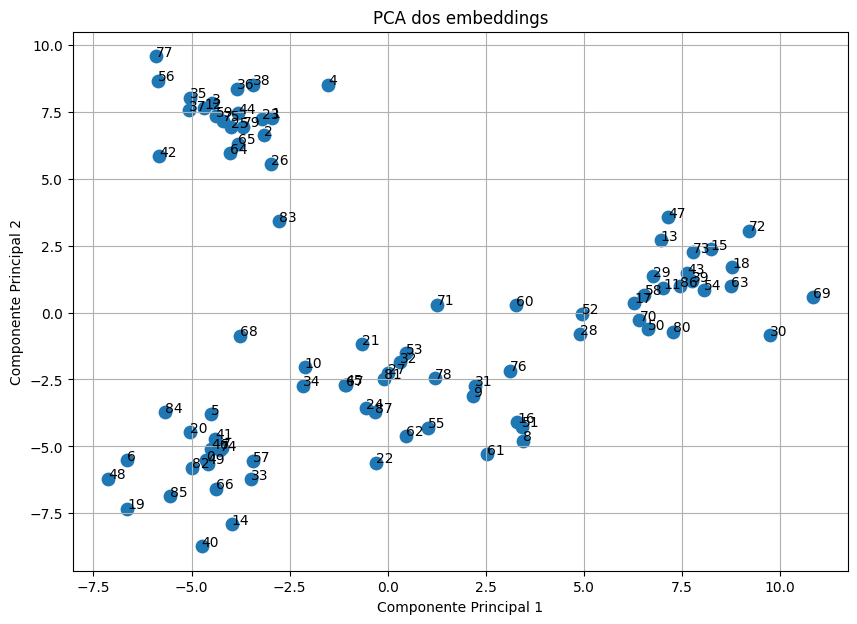

In [ ]:
#Plote os pontos resultantes com matplotlib, identificando possíveis agrupamentos.
plt.figure(figsize=(10, 7))

plt.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    s=80
)

for i, sentence in enumerate(df_pca['sentence']):
    plt.text(
        df_pca['PC1'][i],
        df_pca['PC2'][i],
        str(i), #Acabei usando o numero e checando as frases no sentences pois ao escrever as frases gerou muita sobreposição
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA dos embeddings")

plt.grid(True)
plt.show()

In [ ]:
for i, s in enumerate(sentences):
    print(i, s)


0 I swap butter for olive oil in many recipes.
1 Canberra is the capital of Australia.
2 Ottawa is the capital city of Canada.
3 Paris is the most populated city in France.
4 Tokyo is among the most populous metropolitan areas worldwide.
5 I prefer my coffee with no sugar and a splash of milk.
6 The recipe for pasta carbonara is simple.
7 A pinch of salt enhances sweetness in desserts.
8 Alignment techniques reduce harmful outputs.
9 Explainable AI highlights salient features for decisions.
10 Transformer models enable long-range language dependencies.
11 Black swan events stress-test portfolio resilience.
12 The Sahara Desert spans much of North Africa.
13 Inflation erodes real purchasing power of cash.
14 Aromatics like garlic and onion build flavor early.
15 Value stocks trade at lower multiples relative to fundamentals.
16 Quantization reduces memory with minimal accuracy loss.
17 Tax-loss harvesting offsets capital gains.
18 Investing in technology can be risky.
19 Fermented foods

Analise qualitativamente se há separação entre textos de temas distintos:

Ao analisar qualitativamente o PCA dos embeddings exibidos no gráfico, é possível observar uma separação clara entre grupos de frases com temas distintos. Como utilizei enumerate ao gerar os pontos, consegui comparar facilmente cada posição com sua frase original, o que tornou a interpretação mais direta. A distribuição dos dados sugere quatro clusters temáticos principais. No canto superior esquerdo, forma-se um agrupamento composto por frases relacionadas à geografia, cidades e marcos naturais, como capitais, rios, montanhas e fenômenos geográficos. No canto inferior esquerdo, observa-se um agrupamento de frases ligadas à culinária e técnicas de cozinha. No lado direito do gráfico, há um agrupamento alongado que reúne frases relacionadas a finanças, investimentos e economia. No centro do gráfico localizam-se as frases relacionadas à inteligência artificial e machine learning. Embora os clusters sejam bem definidos, o gráfico apresenta alguns outliers. Alguns pontos aparecerem longe dos clusters que deveriam estar associados. Essas distorções ocorrem porque o PCA reduz embeddings de alta dimensionalidade para apenas duas dimensões, o que pode alterar relações espaciais e causar projeções que parecem inconsistentes, mesmo quando as frases pertencem claramente aos seus respectivos temas.

## t-SNE

Use **t-SNE (t-distributed Stochastic Neighbor Embedding)** para investigar a estrutura local dos dados.  
Diferente do PCA, o t-SNE tenta preservar vizinhanças locais e pode revelar grupos mais sutis.

**Tarefas:**
- Reduza os embeddings para 2D usando `TSNE` do `scikit-learn`.  
- Ajuste parâmetros como `perplexity` e `learning_rate` para comparar resultados.  
- Visualize o mapa e observe se os textos semelhantes ficam próximos.

In [ ]:
#Ajuste parâmetros como perplexity e learning_rate para comparar resultados. mexe ate achar algo legal

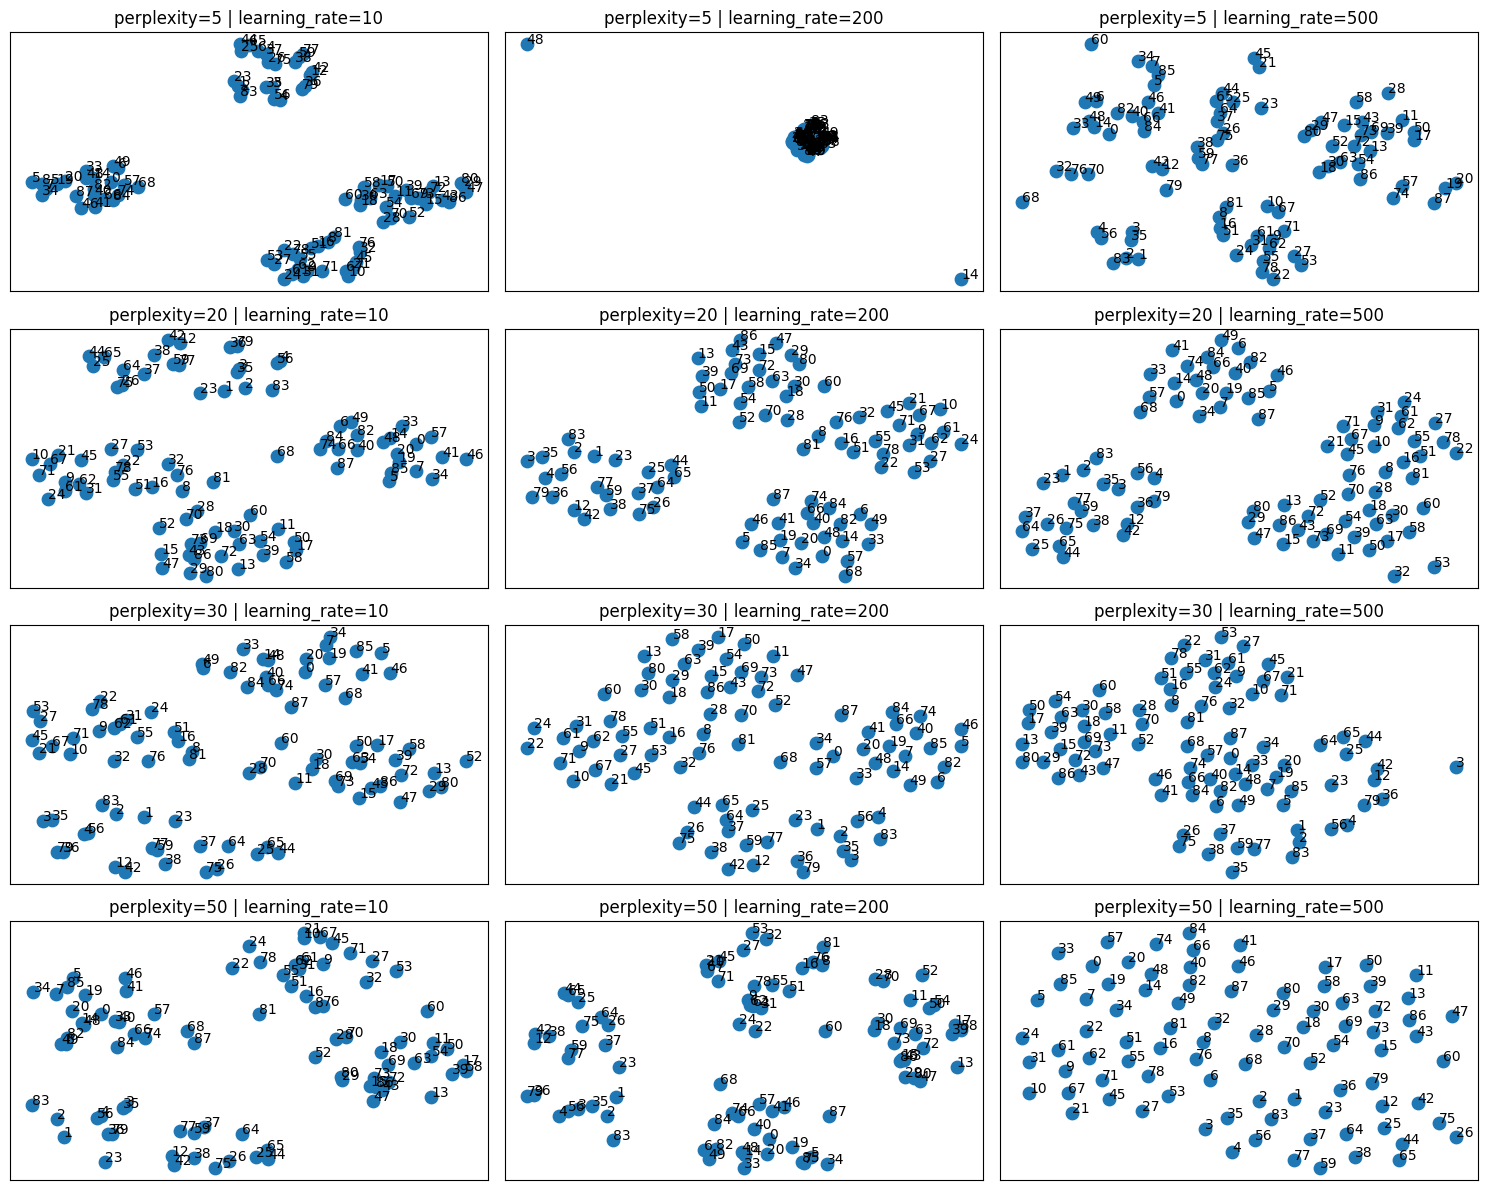

In [ ]:
# Valores a testar
perplexities = [5, 20, 30, 50]
learning_rates = [10, 200, 500]

# Tamanho da grade
n_rows = len(perplexities)
n_cols = len(learning_rates)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(learning_rates):

        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            learning_rate=lr,
            init='random',
            random_state=42
        )

        emb = tsne.fit_transform(embeddings)

        ax = axes[i, j]

        ax.scatter(
            emb[:, 0],
            emb[:, 1],
            s=80
        )

        # Referenciar os pontos
        for idx in range(len(emb)):
            ax.text(
                emb[idx, 0],
                emb[idx, 1],
                str(idx),
            )

        ax.set_title(f"perplexity={perp} | learning_rate={lr}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


Em alguns valores de perplexity/learning rate os dados ou ficaram muito amontoados entre si (exemplo: perplexity= 5 e learning_rate= 200 ) ou em um grande cluster (exemplo: perplexity= 50 e learning_rate= 500) porém alguns valores desenharam clusters bem evidentes como é o caso de perplexity= 20 e learning_rate= 200 e perplexity= 50 e learning_rate= 200 alguns outros também. Analisando esses dois citados anteriormente temos que no caso de perplexity= 20 e learning_rate= 200 analisando o gráfico, é nítido que as frases foram organizadas em "aglomerados" temáticos distintos. Textos sobre Inteligência Artificial e Machine Learning  formaram um grupo coeso no topo. Da mesma forma, frases sobre Finanças e Investimentos  agruparam-se claramente à direita. Os textos de Geografia  criaram um grande cluster à esquerda, enquanto todas as frases sobre Culinária e Comida  se concentraram na parte inferior do gráfico, essa perplexity e learning rate criou quatro clusters densos, compactos e com uma boa separação entre os clusters, mostrando-se dentre os valores testados a melhor perplexity e learning rate. No gráfico que possui perplexity= 50 e learning_rate= 200  obtivemos a mesma separação de grupos porém os grupos estão mais espalhados e menos definidos. Essa separação em quatro grupos foi tematicamente parecida com a de PCA mas expressas de maneira um pouco visualmente distintas, o T-SNE mostra os clusters de maneira densas e mais bem separados enquanto o PCA mostra os grupos mais espalhados e com dois outliers.

## UMAP

Aplique **UMAP (Uniform Manifold Approximation and Projection)** como alternativa ao t-SNE.  
O UMAP é mais eficiente, preserva parte da estrutura global e é útil para visualização e pré-processamento.

**Tarefas:**
- Gere uma projeção 2D dos embeddings com `umap.UMAP`.  
- Experimente variar `n_neighbors` e `min_dist` para observar mudanças na distribuição dos clusters.  
- Compare visualmente com os resultados do PCA e t-SNE.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

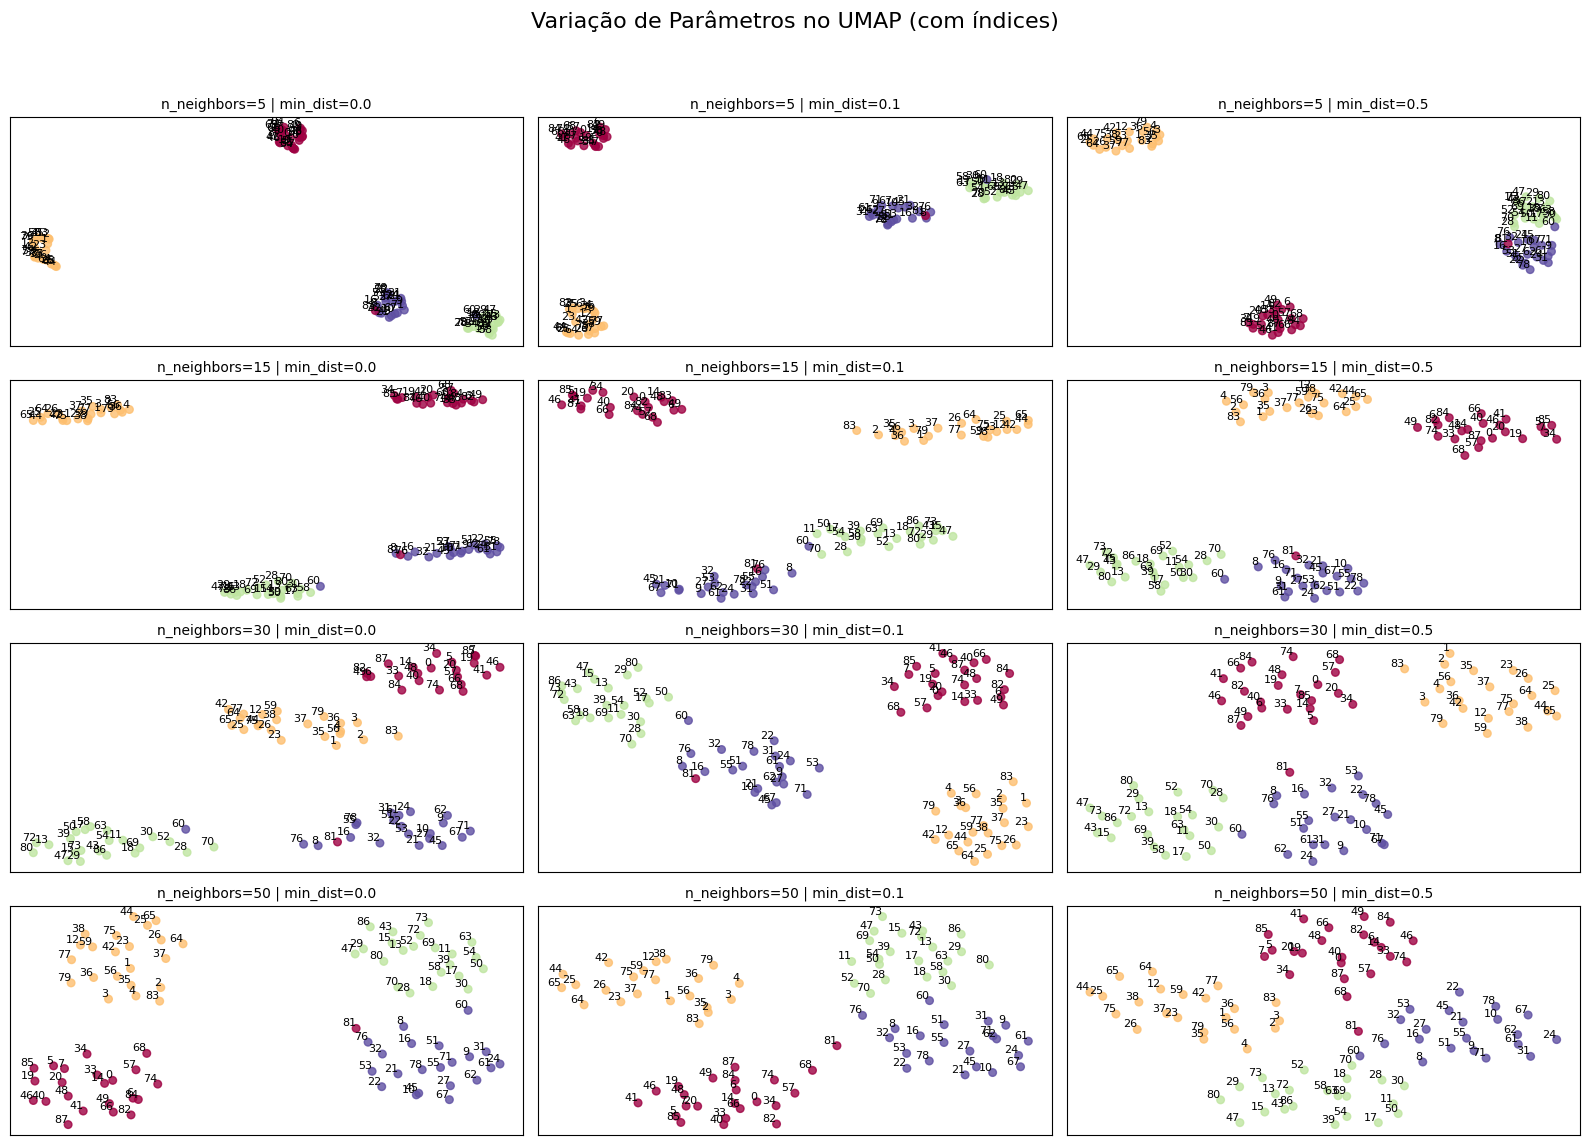

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(embeddings)

# Valores de teste
neighbors_list = [5, 15, 30, 50]
dist_list = [0.0, 0.1, 0.5]

# Configura a grade de gráficos
fig, axes = plt.subplots(len(neighbors_list), len(dist_list), figsize=(16, 12))
fig.suptitle('Variação de Parâmetros no UMAP (com índices)', fontsize=16)

for i, n_neighbors in enumerate(neighbors_list):
    for j, min_dist in enumerate(dist_list):

        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=2,
            random_state=42,
            metric='cosine'
        )

        # Projeta os dados
        embedding_umap = reducer.fit_transform(embeddings)

        # Plota os pontos
        ax = axes[i, j]
        scatter = ax.scatter(
            embedding_umap[:, 0],
            embedding_umap[:, 1],
            c=labels,
            cmap='Spectral',
            s=30,
            alpha=0.8
        )

        #Adicionando os indices
        for idx in range(len(embedding_umap)):
            ax.text(
                embedding_umap[idx, 0],
                embedding_umap[idx, 1],
                str(idx),
                fontsize=8,
                ha='right',
                va='bottom'
            )

        ax.set_title(f"n_neighbors={n_neighbors} | min_dist={min_dist}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

A comparação visual entre os métodos revela que o UMAP atua como um ponto de equilíbrio ideal, superando as limitações específicas tanto do PCA quanto do t-SNE. Ao confrontar o UMAP com o PCA, a diferença mais marcante é a definição das fronteiras. Enquanto o PCA projeta os dados como uma "nuvem" contínua e linear, falhando em separar limites complexos e deixando outliers soltos, o UMAP utiliza um grafo de vizinhos para "puxar" esses pontos para seus respectivos grupos semânticos. Isso resulta em uma visualização muito mais limpa, com espaços vazios que isolam claramente os quatro temas, algo que a linearidade do PCA não consegue alcançar com a mesma precisão.

Já em relação ao t-SNE, a vantagem do UMAP se manifesta na coerência da estrutura global. As imagens mostram que o t-SNE é visualmente instável dependendo dos hiperparâmetros: com perplexidade baixa, ele fragmenta os dados em ilhas sem sentido, e mesmo com a perplexidade ideal, ele gera clusters isolados cuja distância entre si é arbitrária. O UMAP corrige isso ao oferecer flexibilidade: ele consegue replicar o isolamento nítido do t-SNE, mas, ao ajustar o parâmetro n_neighbors para valores maiores (como 30 ou 50), ele preserva a lógica global dos dados. Isso significa que, diferentemente do t-SNE, o UMAP tenta posicionar grupos semanticamente próximos em regiões vizinhas do gráfico, entregando um mapa visual que é, ao mesmo tempo, organizado localmente e coerente globalmente.

## Classificação

Com base nas categorias observadas nos gráficos anteriores, crie uma função simples que receba um texto e classifique-o na categoria mais provável. (que eu defini)

**Tarefas:**
- Use os embeddings existentes e os clusters identificados para rotular automaticamente cada texto.  
- Crie uma função `classificar_texto(texto: str)` que:
  1. Gere o embedding do texto.
  2. Calcule a distância para os clusters identificados.
  3. Retorne o nome do cluster mais próximo.

In [ ]:
#Quantidade de clustes definido anteriormente
N_CLUSTERS = 4

#Gere o embedding do texto.
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings_raw = model.encode(sentences, convert_to_numpy=True)

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_raw)

#Reduzindo quantidade de dimensões com PCA para retirar ruidos
n_components_pca = 50
pca_transformer = PCA(n_components=n_components_pca, random_state=42)
embeddings_pca = pca_transformer.fit_transform(embeddings_scaled)

#Usando UMAP para ficar apenas duas dimensões
umap_transformer = UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42
)
embeddings_final_2d = umap_transformer.fit_transform(embeddings_pca)

#Calcule a distância para os clusters identificados.
kmeans_model = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(embeddings_final_2d)

# Dicionário de Mapeamento
cluster_mapping = {
    0: 'Machine Learning/Deep Learning',
    1: 'Geografia',
    2: 'Culinária/Receitas',
    3: 'Finanças/Economia',
}




/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
def classificar_frase(sentence: str):

    embedding_raw = model.encode([sentence], convert_to_numpy=True)
    embedding_scaled = scaler.transform(embedding_raw)
    embedding_pca = pca_transformer.transform(embedding_scaled)
    embedding_final_2d = umap_transformer.transform(embedding_pca)
    cluster_id = kmeans_model.predict(embedding_final_2d)[0]
    category = cluster_mapping.get(cluster_id, 'Categoria Desconhecida')
    #Retorne o nome do cluster mais próximo.
    print(f"Frase: '{sentence}'")
    print(f"Cluster ID: {cluster_id}")
    print(f"Categoria Prevista: {category}\n")

In [ ]:
#Testes
classificar_frase("Brasilia is the capital of brazil")
classificar_frase("I like AI")
classificar_frase("We need flour to make bread")
classificar_frase("I want to buy bitcoins")

Frase: 'Brasilia is the capital of brazil'
Cluster ID: 1
Categoria Prevista: Geografia

Frase: 'I like AI'
Cluster ID: 0
Categoria Prevista: Machine Learning/Deep Learning

Frase: 'We need flour to make bread'
Cluster ID: 2
Categoria Prevista: Culinária/Receitas

Frase: 'I want to buy bitcoins'
Cluster ID: 3
Categoria Prevista: Finanças/Economia

